In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

from tqdm import tqdm
from gensim.models import CoherenceModel, LdaModel, HdpModel
from gensim.corpora import Dictionary

# Choose the dataset

In [ ]:
# # UCSF data
# # n = 669
# n = 322
# # data_likelihood_folder = "Subphenotyping-for-PASC_test/trained_topic_model_ucsf" # w/o version
# data_likelihood_folder = "Subphenotyping-for-PASC_test/trained_topic_model_ucsf_last" # w/o version
# topic_coherence_folder = "topic_coherence_ucsf_last/"
# # subset = pd.read_csv("preprocessed_n669_to1.csv")
# # subset = pd.read_csv("preprocessed_n534_last.csv")
# subset = pd.read_csv("preprocessed_n322_close700.csv")
# symptoms = ['abdom', 'back', 'balan', 'chest', 'chills', 'concen', 'const', 'cough', 'cramps', 'diarr', 'dizz', 
#             'faint', 'fatig', 'fever', 'head', 'heartrace', 'loss', 'muscle', 'nausea', 'numb', 'odor', 'pain', 
#             'painsex', 'rash', 'runny', 'short', 'sleep', 'smell', 'sore', 'temp', 'vision', 'vomit']
# subset = subset[symptoms].astype(int)

In [ ]:
# # Sinai data
# n = 615
# data_likelihood_folder = "Subphenotyping-for-PASC_test/trained_topic_model_sinai"
# topic_coherence_folder = "topic_coherence_sinai/"
# subset = pd.read_csv("UCSF_8_21_2024_DATAEXPORT_original_survey.csv")
# subset = subset[list(filter(re.compile("currentsymptoms_.*").match, subset.columns))]
# del subset["currentsymptoms_45"]
# del subset["currentsymptoms_46"]

In [ ]:
# Emory and Sinai data
# n = 675
n = 885
# n = 825
data_likelihood_folder = "Subphenotyping-for-PASC_test/trained_topic_model_emory_sinai_n885" 
# data_likelihood_folder = "Subphenotyping-for-PASC_test/trained_topic_model_sinai_n825" 
# topic_coherence_folder = "topic_coherence_emory_sinai/"
topic_coherence_folder = "topic_coherence_emory_sinai_n885/"
# topic_coherence_folder = "topic_coherence_sinai_n825/"
# subset = pd.read_csv("emory_and_sinai_n675.csv")
# subset = pd.read_csv("emory_and_sinai_n885.csv")
subset = pd.read_csv("data_cleaned/emory_and_sinai_n885.csv")
# subset = pd.read_csv("UCSF_2_4_25_most_recent_surveys_100_n825.csv")
subset = subset[list(filter(re.compile("currentsymptoms_.*").match, subset.columns))]
subset = subset.iloc[:, :44]

In [2]:
# # Cardiff data
# n = 318
# data_likelihood_folder = "Subphenotyping-for-PASC_test/trained_topic_model_cardiff_n318"
# topic_coherence_folder = "topic_coherence_cardiff/"
# subset = pd.read_csv("cardiff_data_all_n318.csv")
# del subset["id"]
# del subset["group"]

885 total
9 patients without any symptoms


In [ ]:
texts = []
ct = 0
for index, row in subset.iterrows(): 
    line = []
    for col in subset.columns: 
        if row[col] == 1.0: 
            line.append(col)
#     print(line)
    if len(line) == 0: 
        ct += 1
    texts.append(line)
print(len(texts), "total")
print(ct, "patients without any symptoms")

dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Topic Coherence

In [3]:
# # Single run
# random_state = 1
# coherences = pd.DataFrame(columns = ["num_topics", 'u_mass', 'c_v', 'c_uci', 'c_npmi']) 
# for num_topics in tqdm(range(20, 30), desc="LdaModel for num_topic range"):
#     values = [num_topics]
#     goodLdaModel = LdaModel(corpus=corpus, id2word=dictionary, iterations=50, num_topics=num_topics, random_state = random_state)
#     for coherence in ['u_mass', 'c_v', 'c_uci', 'c_npmi']: 
#         goodcm = CoherenceModel(model=goodLdaModel, texts=texts, dictionary=dictionary, coherence=coherence)
#         values.append(goodcm.get_coherence())
#     coherences = pd.concat([coherences, pd.DataFrame([dict(zip(coherences.columns, values))])], ignore_index=True)
# coherences = coherences.set_index("num_topics")
# coherences

In [3]:
# Multiple runs
for i in range(1, 11): 
    print(i)
    coherences = pd.DataFrame(columns = ["num_topics", 'u_mass', 'c_v', 'c_uci', 'c_npmi']) 
    for num_topics in tqdm(range(2, 82), desc="LdaModel for num_topic range"):
        values = [num_topics]
        goodLdaModel = LdaModel(corpus=corpus, id2word=dictionary, iterations=50, num_topics=num_topics)
        for coherence in ['u_mass', 'c_v', 'c_uci', 'c_npmi']: 
            goodcm = CoherenceModel(model=goodLdaModel, texts=texts, dictionary=dictionary, coherence=coherence)
            values.append(goodcm.get_coherence())
        coherences = pd.concat([coherences, pd.DataFrame([dict(zip(coherences.columns, values))])], ignore_index=True)
    coherences = coherences.set_index("num_topics")
    coherences.to_csv(topic_coherence_folder + "coherences_" + str(i) + ".csv", index = False)

1


LdaModel for num_topic range: 100%|██████████| 80/80 [50:39<00:00, 37.99s/it]


2


LdaModel for num_topic range: 100%|██████████| 80/80 [49:30<00:00, 37.13s/it]


3


...

LdaModel for num_topic range: 100%|██████████| 80/80 [24:32<00:00, 18.41s/it]


9


LdaModel for num_topic range: 100%|██████████| 80/80 [24:51<00:00, 18.64s/it]


10


LdaModel for num_topic range: 100%|██████████| 80/80 [26:01<00:00, 19.52s/it]


In [3]:
coherences = pd.DataFrame()
for i in range(1, 11): 
    file = topic_coherence_folder + "coherences_" + str(i) + ".csv"
    df = pd.read_csv(file)
    print(file)
    if coherences.shape[0] == 0: coherences = df.copy()
    else: coherences = coherences + df
coherences = coherences/10
coherences.index = range(2, 82)
coherences

topic_coherence_emory_sinai_n885/coherences_1.csv
topic_coherence_emory_sinai_n885/coherences_2.csv
topic_coherence_emory_sinai_n885/coherences_3.csv
topic_coherence_emory_sinai_n885/coherences_4.csv
topic_coherence_emory_sinai_n885/coherences_5.csv
topic_coherence_emory_sinai_n885/coherences_6.csv
topic_coherence_emory_sinai_n885/coherences_7.csv
topic_coherence_emory_sinai_n885/coherences_8.csv
topic_coherence_emory_sinai_n885/coherences_9.csv
topic_coherence_emory_sinai_n885/coherences_10.csv


,u_mass,c_v,c_uci,c_npmi
2,-0.899588,0.696963,-0.239191,-0.030660
3,-0.920372,0.693769,-0.243725,-0.030337
4,-0.922399,0.691363,-0.241894,-0.029471
5,-0.945241,0.690925,-0.247308,-0.029659
6,-0.955676,0.693987,-0.247166,-0.029006
...,...,...,...,...
77,-0.987979,0.687294,-0.286387,-0.032980
78,-0.982694,0.686663,-0.283449,-0.032662
79,-0.992463,0.685160,-0.294488,-0.033306
80,-0.991058,0.685990,-0.289414,-0.033081


In [4]:
number_of_topics = 18

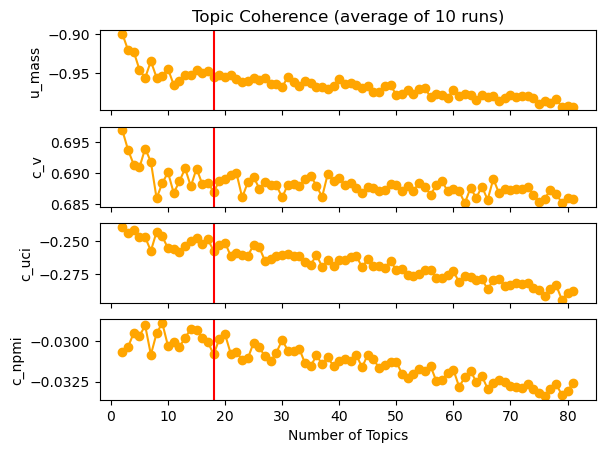

In [5]:
# Plotting results
plot = 411
for c in ["u_mass", "c_v", "c_uci", "c_npmi"]:
    if plot == 411: 
        ax = plt.subplot(plot)
    else: 
        ax = plt.subplot(plot, sharex = ax)
    plt.plot(coherences.index, coherences[c], c = "orange", marker = "o")
    plt.axvline(x = number_of_topics, c = "red")
    plt.ylabel(c)
    if plot == 411: plt.title("Topic Coherence (average of 10 runs)")
    if plot != 414: plt.tick_params('x', labelbottom = False)
    else: 
        plt.tick_params('x')
    x = list(coherences.index)
    y = [round(val, 3) for val in list(coherences[c])]
    plot += 1
a = plt.xlabel("Number of Topics")

# Data Likelihood

cd /mnt/c/Users/bpeng/Documents/pasc_endotyping/Subphenotyping-for-PASC_test/Python\ code\ for\ training\ topic\ modeling

cd Subphenotyping-for-PASC_test/Python\ code\ for\ training\ topic\ modeling

python3 Main_train_topic_model_test.py >> ../output_n885.txt

./run.sh

In [8]:
# # Single run
# number_of_topics = 50
# values = []
# for v in range(1, 2): 
#     for i in range(2, 62): 
#         file = f"Subphenotyping-for-PASC_test/trained_topic_model_sinai_v{v}/PFA_trained_model_n628_k{i}_output.csv"
#         data = pd.read_csv(file)
#         value = list(data["Likelihood mean"])[-1]
#         values.append(value/500)
# a = plt.plot(range(2, 62), values, marker = "o")
# a = plt.plot([number_of_topics, number_of_topics], [min(values), max(values)], color = "red")
# a = plt.xlabel("Number of topic")

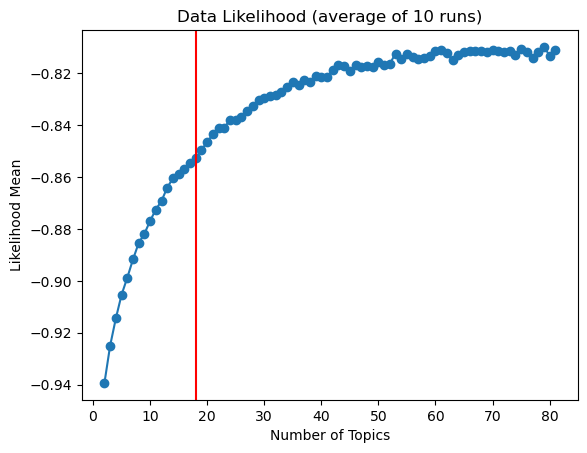

In [6]:
# Multiple runs
number_of_topics = 18
all_values = [0]*len(range(2, 82))
values = []
for v in range(1, 11): 
    values = []
    for i in range(2, 82): 
        file = f"{data_likelihood_folder}_v{v}/PFA_trained_model_n{n}_k{i}_output.csv"
        data = pd.read_csv(file)
        value = list(data["Likelihood mean"])[-1]
        values.append(value/500)
    for x in range(len(all_values)): 
        all_values[x] = all_values[x] + values[x]
#     print(len(all_values), sum(all_values))
likelihoods = pd.DataFrame()
likelihoods["num_topics"] = list(range(2, 82))
likelihoods["likelihood"] = all_values
likelihoods["likelihood"] = likelihoods["likelihood"]/10
a = plt.plot(likelihoods["num_topics"], likelihoods["likelihood"], marker = "o")
a = plt.axvline(x = number_of_topics, color = "red")
a = plt.title("Data Likelihood (average of 10 runs)")
a = plt.xlabel("Number of Topics")
a = plt.ylabel("Likelihood Mean")

In [10]:
# # Single run
# file = "C:/Users/bpeng/Documents/pasc_endotyping/Subphenotyping-for-PASC_test/output_n1265.txt"
# data = pd.read_csv(file, sep = ";", header = None)
# values = []
# for index, row in data.iterrows(): 
#     keep = False
#     for r in row: 
#         if keep: values.append(float(r.split(" ")[-1]))
#         elif "Epoch 999" in r: keep = True
# data = pd.DataFrame({"num_topics": range(2, len(values) + 2), "likelihood": values})
# a = plt.plot(data["num_topics"], data["likelihood"]/500, marker = "o")
# a = plt.plot([number_of_topics, number_of_topics], [-0.66, -0.56], color = "red")
# a = plt.xlabel("Number of topic")

# Topic Coherence and Data Likelihood

In [7]:
combined = likelihoods.copy()
combined["u_mass"] = list(coherences["u_mass"])
combined["c_v"] = list(coherences["c_v"])
combined["c_uci"] = list(coherences["c_uci"])
combined["c_npmi"] = list(coherences["c_npmi"])

# combined["u_mass"] = [val**2 for val in combined["u_mass"]]
# combined["c_v"] = [val**2 for val in combined["c_v"]]
# combined["c_uci"] = [val**2 for val in combined["c_uci"]]
# combined["c_npmi"] = [val**2 for val in combined["c_npmi"]]
combined = combined[(combined["num_topics"] > 9) & (combined["num_topics"] < 51)]
combined

,num_topics,likelihood,u_mass,c_v,c_uci,c_npmi
8,10,-0.876901,-0.944474,0.690118,-0.255596,-0.030284
9,11,-0.872535,-0.964356,0.686759,-0.256444,-0.030015
10,12,-0.869227,-0.959382,0.688655,-0.258712,-0.030343
11,13,-0.864066,-0.952096,0.690754,-0.253620,-0.029773
12,14,-0.860484,-0.951925,0.687841,-0.250237,-0.029217
13,15,-0.858815,-0.945963,0.690740,-0.247648,-0.029269
14,16,-0.857077,-0.949540,0.688233,-0.252729,-0.029753
15,17,-0.854761,-0.946330,0.688398,-0.248813,-0.030052
16,18,-0.852797,-0.954298,0.686973,-0.257648,-0.030801
17,19,-0.849540,-0.951410,0.688711,-0.252837,-0.029835


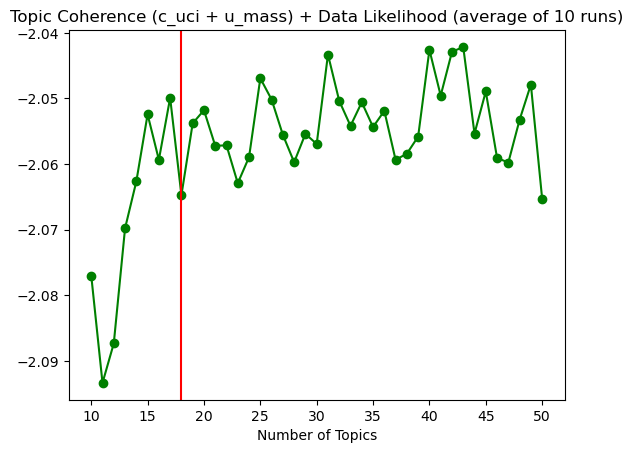

In [8]:
a = plt.plot(combined["num_topics"], combined["c_uci"] + combined["u_mass"] + combined["likelihood"], marker = "o", color = "green")
a = plt.axvline(x = 18, color = "red")
# a = plt.axvline(x = 19, color = "red")
# a = plt.ylim(-2.2, -1.8)
# a = plt.ylim(-3.1, -1.8)
# a = plt.ylim(-3.1, -1.8)
a = plt.title(f"Topic Coherence (c_uci + u_mass) + Data Likelihood (average of 10 runs)")
a = plt.xlabel("Number of Topics")

In [26]:
pd.DataFrame(combined["c_uci"] + combined["u_mass"] + combined["likelihood"]).sort_values(0, ascending = False).head(5)

,0
31,-1.995347
13,-1.997711
15,-1.998774
19,-2.000659
21,-2.000691


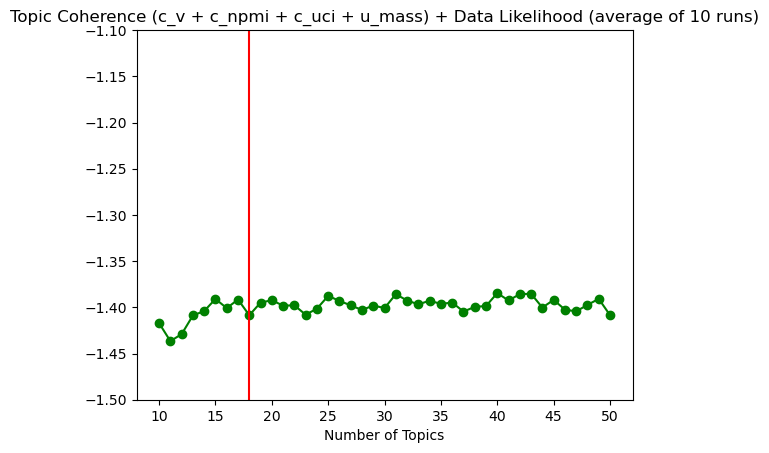

In [9]:
a = plt.plot(combined["num_topics"], combined["c_v"] + combined["c_npmi"] + combined["c_uci"] + combined["u_mass"] + combined["likelihood"], marker = "o", color = "green")
a = plt.axvline(x = 18, color = "red")
# a = plt.axvline(x = 19, color = "red")
a = plt.ylim(-1.5, -1.1)
# a = plt.ylim(-3.1, -1.8)
# a = plt.ylim(-3.1, -1.8)
a = plt.title(f"Topic Coherence (c_v + c_npmi + c_uci + u_mass) + Data Likelihood (average of 10 runs)")
a = plt.xlabel("Number of Topics")

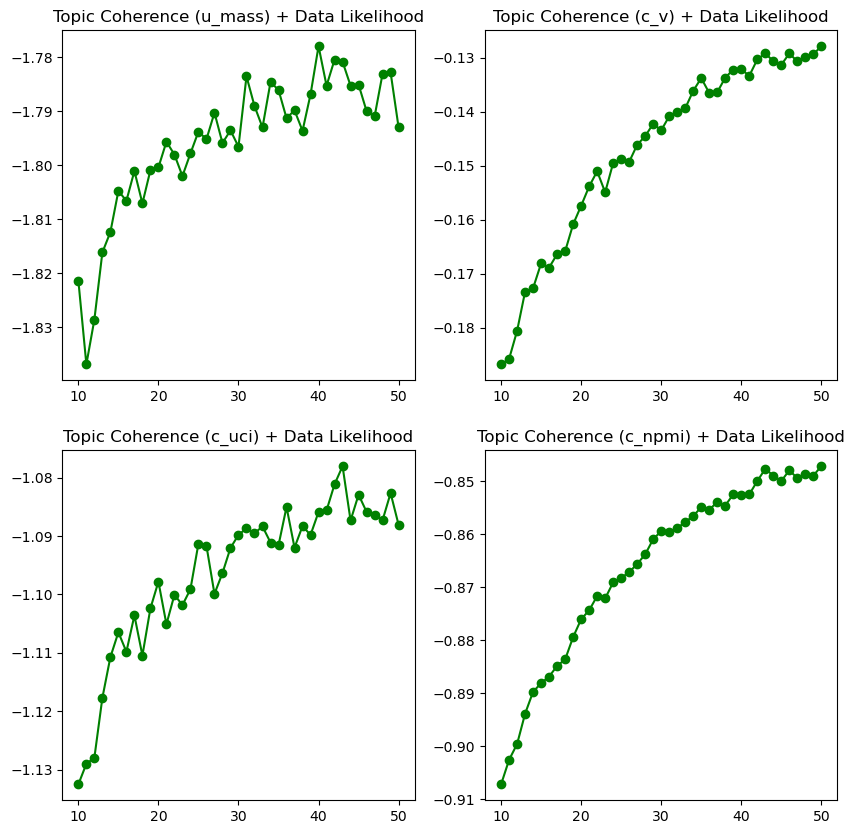

In [10]:
fig, axes = plt.subplots(2, 2, figsize = (10, 10))
i = 28

axes[0, 0].plot(combined["num_topics"], combined["u_mass"] + combined["likelihood"], marker = "o", color = "green")
# axes[0, 0].plot([i, i], [min(combined["u_mass"] + combined["likelihood"]), max(combined["u_mass"] + combined["likelihood"])], color = "red")
a = axes[0, 0].set_title(f"Topic Coherence (u_mass) + Data Likelihood")

axes[0, 1].plot(combined["num_topics"], combined["c_v"] + combined["likelihood"], marker = "o", color = "green")
# axes[0, 1].plot([i, i], [min(combined["c_v"] + combined["likelihood"]), max(combined["c_v"] + combined["likelihood"])], color = "red")
a = axes[0, 1].set_title(f"Topic Coherence (c_v) + Data Likelihood")

axes[1, 0].plot(combined["num_topics"], combined["c_uci"] + combined["likelihood"], marker = "o", color = "green")
# axes[1, 0].plot([i, i], [min(combined["c_uci"] + combined["likelihood"]), max(combined["c_uci"] + combined["likelihood"])], color = "red")
a = axes[1, 0].set_title(f"Topic Coherence (c_uci) + Data Likelihood")

axes[1, 1].plot(combined["num_topics"], combined["c_npmi"] + combined["likelihood"], marker = "o", color = "green")
# axes[1, 1].plot([i, i], [min(combined["c_npmi"] + combined["likelihood"]), max(combined["c_npmi"] + combined["likelihood"])], color = "red")
a = axes[1, 1].set_title(f"Topic Coherence (c_npmi) + Data Likelihood")

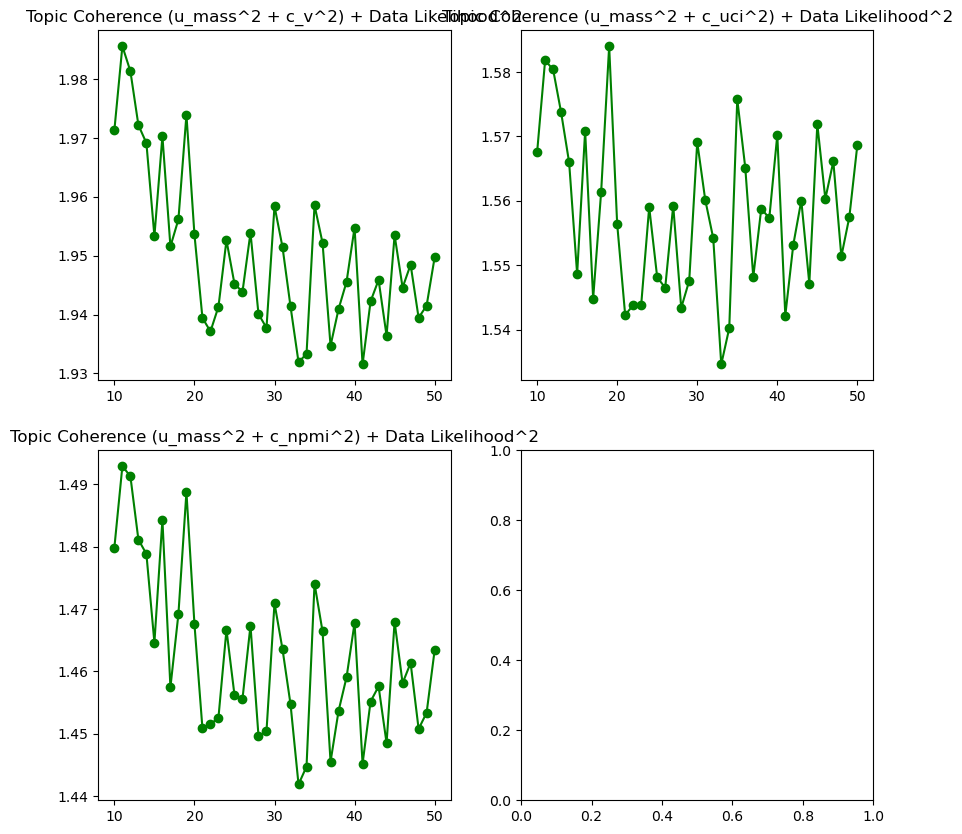

In [57]:
fig, axes = plt.subplots(2, 2, figsize = (10, 10))
i = 28

values = []
for a, b, c in zip(combined["u_mass"], combined["c_v"], combined["likelihood"]): values.append(a*a + b*b + c*c)
axes[0, 0].plot(combined["num_topics"], values, marker = "o", color = "green")
a = axes[0, 0].set_title(f"Topic Coherence (u_mass^2 + c_v^2) + Data Likelihood^2")

values = []
for a, b, c in zip(combined["u_mass"], combined["c_uci"], combined["likelihood"]): values.append(a*a + b*b + c*c)
axes[0, 1].plot(combined["num_topics"], values, marker = "o", color = "green")
a = axes[0, 1].set_title(f"Topic Coherence (u_mass^2 + c_uci^2) + Data Likelihood^2")

values = []
for a, b, c in zip(combined["u_mass"], combined["c_npmi"], combined["likelihood"]): values.append(a*a + b*b + c*c)
axes[1, 0].plot(combined["num_topics"], values, marker = "o", color = "green")
a = axes[1, 0].set_title(f"Topic Coherence (u_mass^2 + c_npmi^2) + Data Likelihood^2")

# values = []
# for a, b in zip(combined["c_npmi"], combined["likelihood"]): values.append(a*a + b*b)
# axes[1, 1].plot(combined["num_topics"], values, marker = "o", color = "green")
# a = axes[1, 1].set_title(f"Topic Coherence (c_npmi^2) + Data Likelihood^2")